In [1]:
import numpy as np
import matplotlib.pyplot as plt


np.random.seed(42)  # so your numbers match this walkthrough
np.set_printoptions(precision=2, suppress=True)

In [2]:
sentence = ["The", "trophy", "didn't", "fit", "because", "it", "was", "big"]
d_model = 8  # size of each word's vector — real BERT uses 768

# one random vector per word, stacked into a matrix: shape (num_words, d_model)
X = np.random.randn(len(sentence), d_model)

print("Sentence:", sentence)
print("Shape of X (num_words x d_model):", X.shape)
print(X)

Sentence: ['The', 'trophy', "didn't", 'fit', 'because', 'it', 'was', 'big']
Shape of X (num_words x d_model): (8, 8)
[[ 0.5  -0.14  0.65  1.52 -0.23 -0.23  1.58  0.77]
 [-0.47  0.54 -0.46 -0.47  0.24 -1.91 -1.72 -0.56]
 [-1.01  0.31 -0.91 -1.41  1.47 -0.23  0.07 -1.42]
 [-0.54  0.11 -1.15  0.38 -0.6  -0.29 -0.6   1.85]
 [-0.01 -1.06  0.82 -1.22  0.21 -1.96 -1.33  0.2 ]
 [ 0.74  0.17 -0.12 -0.3  -1.48 -0.72 -0.46  1.06]
 [ 0.34 -1.76  0.32 -0.39 -0.68  0.61  1.03  0.93]
 [-0.84 -0.31  0.33  0.98 -0.48 -0.19 -1.11 -1.2 ]]


In [3]:
def positional_encoding(seq_len, d_model):
    pos = np.arange(seq_len)[:, np.newaxis]
    i = np.arange(d_model)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
    angles = pos * angle_rates
    pe = np.zeros((seq_len, d_model))
    pe[:, 0::2] = np.sin(angles[:, 0::2])
    pe[:, 1::2] = np.cos(angles[:, 1::2])
    return pe

PE = positional_encoding(len(sentence), d_model)
X = X + PE   # inject position information into every word's vector

print("Positional encoding shape:", PE.shape)
print(PE)

Positional encoding shape: (8, 8)
[[ 0.    1.    0.    1.    0.    1.    0.    1.  ]
 [ 0.84  0.54  0.1   1.    0.01  1.    0.    1.  ]
 [ 0.91 -0.42  0.2   0.98  0.02  1.    0.    1.  ]
 [ 0.14 -0.99  0.3   0.96  0.03  1.    0.    1.  ]
 [-0.76 -0.65  0.39  0.92  0.04  1.    0.    1.  ]
 [-0.96  0.28  0.48  0.88  0.05  1.    0.    1.  ]
 [-0.28  0.96  0.56  0.83  0.06  1.    0.01  1.  ]
 [ 0.66  0.75  0.64  0.76  0.07  1.    0.01  1.  ]]


In [4]:
d_k = 8  # dimension of Q and K (must match for the dot product to work)
d_v = 8  # dimension of V

W_q = np.random.randn(d_model, d_k) * 0.1
W_k = np.random.randn(d_model, d_k) * 0.1
W_v = np.random.randn(d_model, d_v) * 0.1

Q = X @ W_q   # shape: (num_words, d_k)
K = X @ W_k   # shape: (num_words, d_k)
V = X @ W_v   # shape: (num_words, d_v)

print("Q shape:", Q.shape)
print("K shape:", K.shape)
print("V shape:", V.shape)

Q shape: (8, 8)
K shape: (8, 8)
V shape: (8, 8)


In [5]:
scores = Q @ K.T / np.sqrt(d_k)

print("Raw attention scores (before softmax):")
print(scores)
print("\nShape:", scores.shape, "-> one score for every (word, word) pair")

Raw attention scores (before softmax):
[[ 0.02 -0.04 -0.04 -0.    0.02  0.01 -0.01 -0.08]
 [-0.09 -0.01 -0.06 -0.09 -0.05  0.   -0.04  0.03]
 [ 0.03 -0.01 -0.03  0.03 -0.01  0.04  0.03 -0.03]
 [ 0.02  0.24 -0.   -0.1  -0.18  0.   -0.25  0.2 ]
 [-0.12  0.26  0.07 -0.03 -0.05 -0.   -0.21  0.18]
 [-0.01  0.13  0.   -0.09 -0.09 -0.02 -0.16  0.14]
 [ 0.09  0.16  0.05  0.02 -0.06 -0.   -0.13  0.08]
 [-0.03  0.01 -0.03  0.01 -0.04  0.03 -0.05 -0.04]]

Shape: (8, 8) -> one score for every (word, word) pair


In [6]:
def softmax(x):
    x = x - np.max(x, axis=-1, keepdims=True)  # stability trick, doesn't change the result
    e = np.exp(x)
    return e / np.sum(e, axis=-1, keepdims=True)

attention_weights = softmax(scores)

print("Attention weights (each row sums to 1.0):")
print(attention_weights)
print("\nRow sums (sanity check, should all be 1.0):", attention_weights.sum(axis=1))

Attention weights (each row sums to 1.0):
[[0.13 0.12 0.12 0.13 0.13 0.13 0.13 0.12]
 [0.12 0.13 0.12 0.12 0.12 0.13 0.12 0.13]
 [0.13 0.12 0.12 0.13 0.12 0.13 0.13 0.12]
 [0.13 0.16 0.12 0.11 0.1  0.12 0.1  0.15]
 [0.11 0.16 0.13 0.12 0.12 0.12 0.1  0.15]
 [0.13 0.14 0.13 0.12 0.11 0.12 0.11 0.14]
 [0.13 0.14 0.13 0.12 0.11 0.12 0.11 0.13]
 [0.12 0.13 0.12 0.13 0.12 0.13 0.12 0.12]]

Row sums (sanity check, should all be 1.0): [1. 1. 1. 1. 1. 1. 1. 1.]


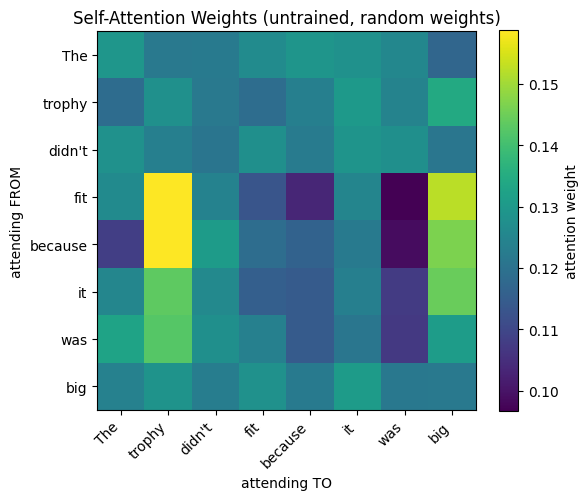


'it' attends most strongly to: big


In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(attention_weights, cmap="viridis")
ax.set_xticks(range(len(sentence)))
ax.set_yticks(range(len(sentence)))
ax.set_xticklabels(sentence, rotation=45, ha="right")
ax.set_yticklabels(sentence)
ax.set_xlabel("attending TO")
ax.set_ylabel("attending FROM")
ax.set_title("Self-Attention Weights (untrained, random weights)")
plt.colorbar(im, label="attention weight")
plt.tight_layout()
plt.show()

it_index = sentence.index("it")
print(f"\n'{sentence[it_index]}' attends most strongly to:",
      sentence[np.argmax(attention_weights[it_index])])

In [8]:
output = attention_weights @ V   # shape: (num_words, d_v)

print("Output shape:", output.shape, "-> same shape as input, but now context-aware")
print(output)

Output shape: (8, 8) -> same shape as input, but now context-aware
[[ 0.2   0.1  -0.12  0.15  0.46  0.01 -0.14 -0.11]
 [ 0.19  0.11 -0.12  0.15  0.46  0.   -0.13 -0.11]
 [ 0.2   0.1  -0.12  0.16  0.46  0.   -0.14 -0.11]
 [ 0.18  0.1  -0.11  0.14  0.44 -0.02 -0.11 -0.11]
 [ 0.18  0.1  -0.12  0.13  0.44 -0.01 -0.11 -0.1 ]
 [ 0.18  0.1  -0.11  0.14  0.45 -0.01 -0.12 -0.11]
 [ 0.19  0.09 -0.12  0.14  0.45 -0.01 -0.13 -0.11]
 [ 0.2   0.1  -0.12  0.15  0.46  0.   -0.14 -0.11]]


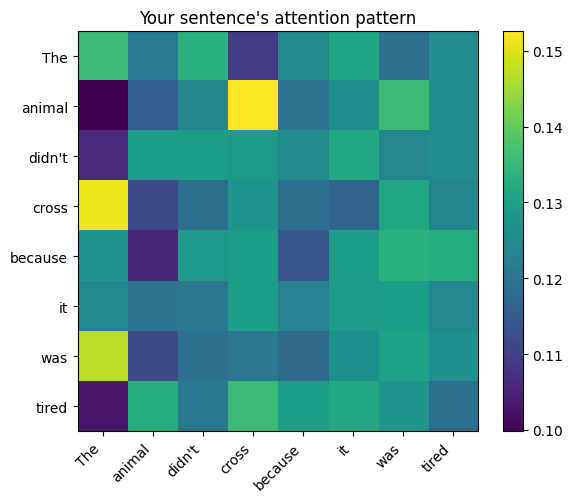

In [9]:
def self_attention(X, W_q, W_k, W_v):
    d_k = W_q.shape[1]
    Q = X @ W_q
    K = X @ W_k
    V = X @ W_v
    scores = Q @ K.T / np.sqrt(d_k)
    weights = softmax(scores)
    output = weights @ V
    return output, weights

# --- Try your own sentence here ---
my_sentence = ["The", "animal", "didn't", "cross", "because", "it", "was", "tired"]
X_new = np.random.randn(len(my_sentence), d_model) + positional_encoding(len(my_sentence), d_model)

out, weights = self_attention(X_new, W_q, W_k, W_v)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(weights, cmap="viridis")
ax.set_xticks(range(len(my_sentence))); ax.set_yticks(range(len(my_sentence)))
ax.set_xticklabels(my_sentence, rotation=45, ha="right")
ax.set_yticklabels(my_sentence)
plt.colorbar(im)
plt.title("Your sentence's attention pattern")
plt.tight_layout()
plt.show()

Multi-head output shape: (8, 8) -> concatenation of 4 heads


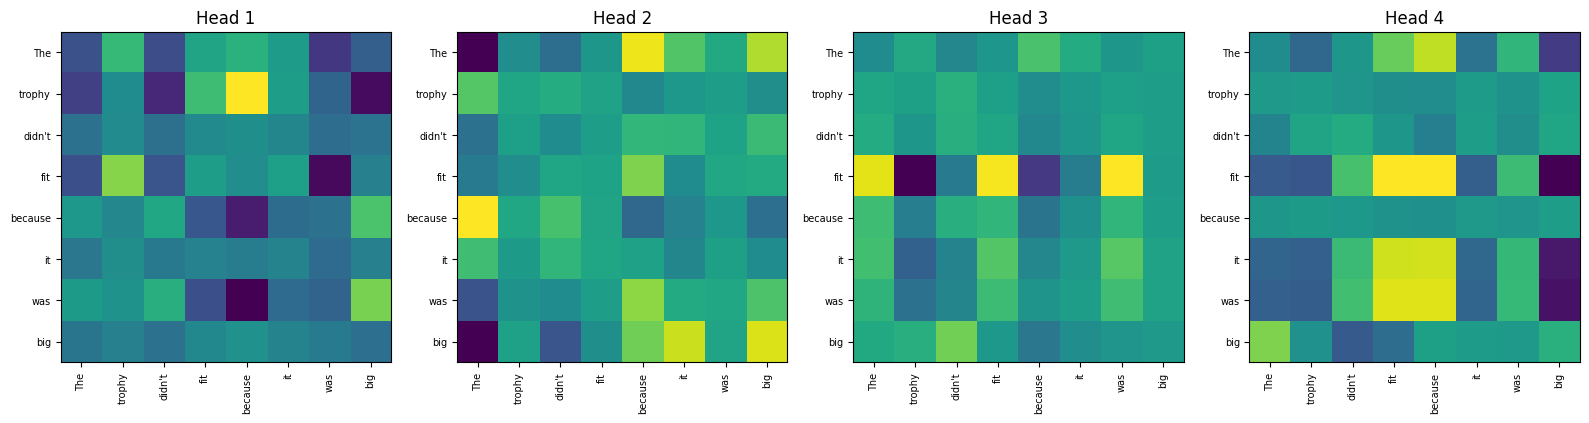


Notice each head produces a *different* attention pattern — with real training, each would learn a different specialty.


In [10]:
def multi_head_attention(X, n_heads, d_model):
    d_k = d_model // n_heads
    outputs = []
    all_weights = []
    for head in range(n_heads):
        W_q = np.random.randn(d_model, d_k) * 0.1
        W_k = np.random.randn(d_model, d_k) * 0.1
        W_v = np.random.randn(d_model, d_k) * 0.1
        out, weights = self_attention(X, W_q, W_k, W_v)
        outputs.append(out)
        all_weights.append(weights)
    concatenated = np.concatenate(outputs, axis=-1)  # shape: (num_words, d_model)
    return concatenated, all_weights

n_heads = 4
mh_output, head_weights = multi_head_attention(X, n_heads, d_model)

print("Multi-head output shape:", mh_output.shape, f"-> concatenation of {n_heads} heads")

fig, axes = plt.subplots(1, n_heads, figsize=(16, 4))
for i, (ax, w) in enumerate(zip(axes, head_weights)):
    im = ax.imshow(w, cmap="viridis")
    ax.set_title(f"Head {i+1}")
    ax.set_xticks(range(len(sentence))); ax.set_yticks(range(len(sentence)))
    ax.set_xticklabels(sentence, rotation=90, fontsize=7)
    ax.set_yticklabels(sentence, fontsize=7)
plt.tight_layout()
plt.show()
print("\nNotice each head produces a *different* attention pattern — with real training, each would learn a different specialty.")

In [11]:
!pip install -q transformers torch


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import torch
from transformers import BertTokenizer, BertModel

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertModel.from_pretrained("bert-base-uncased", output_attentions=True)
model.eval()

text = "The trophy didn't fit in the suitcase because it was too big"
inputs = tokenizer(text, return_tensors="pt")
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

with torch.no_grad():
    outputs = model(**inputs)

# outputs.attentions is a tuple: one tensor per layer, shape (batch, n_heads, seq_len, seq_len)
attentions = outputs.attentions
print(f"Number of layers: {len(attentions)}, heads per layer: {attentions[0].shape[1]}")
print("Tokens:", tokens)

c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Dell\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administra

Number of layers: 12, heads per layer: 12
Tokens: ['[CLS]', 'the', 'trophy', 'didn', "'", 't', 'fit', 'in', 'the', 'suitcase', 'because', 'it', 'was', 'too', 'big', '[SEP]']


'it' (real, trained BERT, layer 5 head 3) attends most strongly to: [SEP]


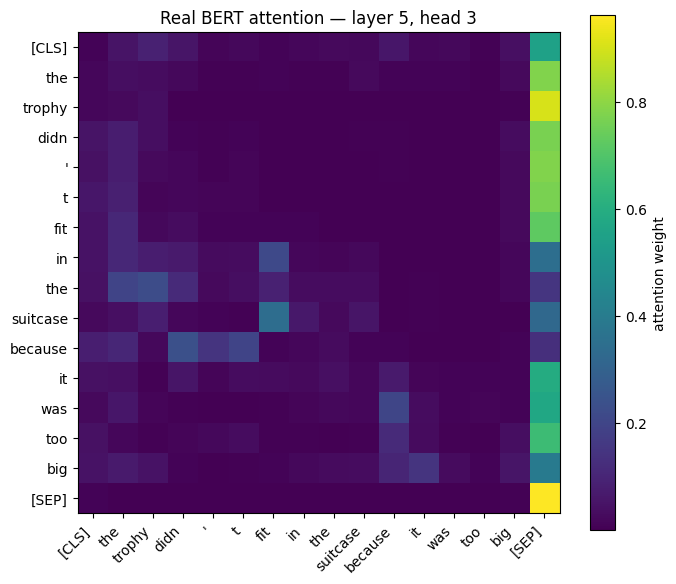

In [13]:
# Pick a layer and head to visualize (try changing these numbers!)
layer, head = 5, 3
attn = attentions[layer][0, head].numpy()

it_idx = tokens.index("it")
print(f"'it' (real, trained BERT, layer {layer} head {head}) attends most strongly to:",
      tokens[np.argmax(attn[it_idx])])

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(attn, cmap="viridis")
ax.set_xticks(range(len(tokens))); ax.set_yticks(range(len(tokens)))
ax.set_xticklabels(tokens, rotation=45, ha="right")
ax.set_yticklabels(tokens)
plt.colorbar(im, label="attention weight")
plt.title(f"Real BERT attention — layer {layer}, head {head}")
plt.tight_layout()
plt.show()